## NZ Health Survey — Exploratory Data Analysis
This notebook explores the raw NZ Health Survey 2024/25 dataset before cleaning. 
The goal is to understand the data structure, identify quality issues, and document 
decisions made prior to the cleaning pipeline.

(47708, 19)
population                        str
short.description                 str
year                            int64
group                             str
total                         float64
flag_for_publishing               str
total.low.CI                  float64
total.high.CI                 float64
male                          float64
male_flag_for_publishing          str
male.low.CI                   float64
male.high.CI                  float64
female                        float64
female_flag_for_publishing        str
female.low.CI                 float64
female.high.CI                float64
estimated.number              float64
estimated.number.low.CI       float64
estimated.number.high.CI      float64
dtype: object
population                        0
short.description                 0
year                              0
group                             0
total                           163
flag_for_publishing           43555
total.low.CI                    313


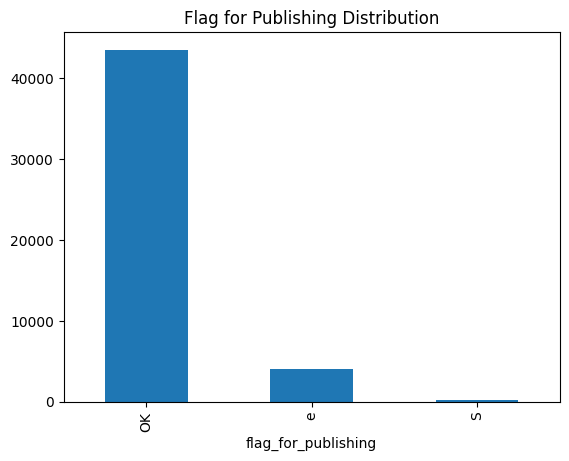

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/gemil/Data/nz-health-survey-2024-25-prevalences.csv")

# Basic shape
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# Unique values in key columns
print(df['short.description'].nunique())  # how many indicators?
print(df['group'].unique())
print(df['year'].unique())
print(df['flag_for_publishing'].value_counts(dropna=False))

# Distribution of suppressed vs publishable
df['flag_for_publishing'].fillna('OK').value_counts().plot(kind='bar')
plt.title('Flag for Publishing Distribution')
plt.show()

## 6. Summary of Cleaning Decisions

Based on this exploration the following decisions were made for the cleaning 
pipeline:

| Issue | Decision | Script |
|---|---|---|
| Null flags | Fill with 'OK' to indicate publishable | 02_clean.py |
| Suppressed values (S) | Set numeric value to null, retain flag as boolean | 02_clean.py |
| Column names | Rename to snake_case for consistency | 02_clean.py |
| 72 columns | Reduce to ~20 meaningful columns | 02_clean.py |
| group values | Categorise into 6 group_category types | 03_transform.py |
| No gender gap column | Derive from male/female columns | 03_transform.py |

See `02_clean.py` and `03_transform.py` for implementation.